# Getting started with TinyTimeMixer (TTM)

This notebooke demonstrates the usage of a pre-trained `TinyTimeMixer` model for several multivariate time series forecasting tasks. For details related to model architecture, refer to the [TTM paper](https://arxiv.org/pdf/2401.03955.pdf).

In this example, we will use a pre-trained TTM-512-96 model. That means the TTM model can take an input of 512 time points (`context_length`), and can forecast upto 96 time points (`forecast_length`) in the future. We will use the pre-trained TTM in two settings:
1. **Zero-shot**: The pre-trained TTM will be directly used to evaluate on the `test` split of the target data. Note that the TTM was NOT pre-trained on the target data.
2. **Few-shot**: The pre-trained TTM will be quickly fine-tuned on only 5% of the `train` split of the target data, and subsequently, evaluated on the `test` part of the target data.

Note: Alternatively, this notebook can be modified to try any other TTM model from a suite of TTM models. For details, visit the [Hugging Face TTM Model Repository](https://huggingface.co/ibm-granite/granite-timeseries-ttm-r2).

1. IBM Granite TTM-R1 pre-trained models can be found here: [Granite-TTM-R1 Model Card](https://huggingface.co/ibm-granite/granite-timeseries-ttm-r1)
2. IBM Granite TTM-R2 pre-trained models can be found here: [Granite-TTM-R2 Model Card](https://huggingface.co/ibm-granite/granite-timeseries-ttm-r2)
3. Research-use (non-commercial use only) TTM-R2 pre-trained models can be found here: [Research-Use-TTM-R2](https://huggingface.co/ibm-research/ttm-research-r2)

## Install `tsfm` 
**[Optional for Local Run / Mandatory for Google Colab]**  
Run the below cell to install `tsfm`. Skip if already installed.

In [1]:
# Install the tsfm library
# ! pip install "tsfm_public[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git@v0.2.18"

## Imports

In [2]:
import math
import os
import sys
import tempfile

sys.path.append('/u/kyeo/granite-tsfm')
#sys.path.append('/u/kyeo/granite-tsfm/tsfm_public/toolkit')

import pandas as pd
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed
from transformers.integrations import INTEGRATION_TO_CALLBACK

from tsfm_public import TimeSeriesPreprocessor, TrackingCallback, count_parameters, get_datasets
from tsfm_public.toolkit.get_model import get_model
from tsfm_public.toolkit.lr_finder import optimal_lr_finder
from tsfm_public.toolkit.visualization import plot_predictions

In [3]:
import warnings


# Suppress all warnings
warnings.filterwarnings("ignore")

### Important arguments

In [4]:
# Set seed for reproducibility
SEED = 42
set_seed(SEED)

# TTM Model path. The default model path is Granite-R2. Below, you can choose other TTM releases.
TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"
# TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r1"
# TTM_MODEL_PATH = "ibm-research/ttm-research-r2"

# Context length, Or Length of the history.
# Currently supported values are: 512/1024/1536 for Granite-TTM-R2 and Research-Use-TTM-R2, and 512/1024 for Granite-TTM-R1
CONTEXT_LENGTH = 512

# Granite-TTM-R2 supports forecast length upto 720 and Granite-TTM-R1 supports forecast length upto 96
PREDICTION_LENGTH = 96

TARGET_DATASET = "etth1"
dataset_path = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"


# Results dir
OUT_DIR = "ttm_finetuned_models/"

# Data processing

In [5]:
# Dataset
TARGET_DATASET = "etth1"
dataset_path = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
timestamp_column = "date"
id_columns = []  # mention the ids that uniquely identify a time-series.

target_columns = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
split_config = {
    "train": [0, 8640],
    "valid": [8640, 11520],
    "test": [
        11520,
        14400,
    ],
}
# Understanding the split config -- slides

data = pd.read_csv(
    dataset_path,
    parse_dates=[timestamp_column],
)

column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": id_columns,
    "target_columns": target_columns,
    "control_columns": [],
}

## Zero-shot evaluation method

In [6]:
def zeroshot_eval(dataset_name, batch_size, context_length=512, forecast_length=96):
    # Get data

    tsp = TimeSeriesPreprocessor(
        **column_specifiers,
        context_length=context_length,
        prediction_length=forecast_length,
        scaling=True,
        encode_categorical=False,
        scaler_type="standard",
    )

    dset_train, dset_valid, dset_test = get_datasets(tsp, data, split_config)

    # Load model
    zeroshot_model = get_model(TTM_MODEL_PATH, context_length=context_length, prediction_length=forecast_length)

    temp_dir = tempfile.mkdtemp()
    # zeroshot_trainer
    zeroshot_trainer = Trainer(
        model=zeroshot_model,
        args=TrainingArguments(
            output_dir=temp_dir,
            per_device_eval_batch_size=batch_size,
            seed=SEED,
            report_to="none",
        ),
    )
    # evaluate = zero-shot performance
    print("+" * 20, "Test MSE zero-shot", "+" * 20)
    zeroshot_output = zeroshot_trainer.evaluate(dset_test)
    print(zeroshot_output)

    # get predictions

    predictions_dict = zeroshot_trainer.predict(dset_test)

    predictions_np = predictions_dict.predictions[0]

    print(predictions_np.shape)

    # get backbone embeddings (if needed for further analysis)

    backbone_embedding = predictions_dict.predictions[1]

    print(backbone_embedding.shape)

    # plot
    plot_predictions(
        model=zeroshot_trainer.model,
        dset=dset_test,
        plot_dir=os.path.join(OUT_DIR, dataset_name),
        plot_prefix="test_zeroshot",
        indices=[685, 118, 902, 1984, 894, 967, 304, 57, 265, 1015],
        channel=0,
    )

# Zeroshot

INFO:p-2827180:t-22896113178432:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-2827180:t-22896113178432:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = main.
INFO:p-2827180:t-22896113178432:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 96


++++++++++++++++++++ Test MSE zero-shot ++++++++++++++++++++


{'eval_loss': 0.3628121316432953, 'eval_runtime': 0.7846, 'eval_samples_per_second': 3549.795, 'eval_steps_per_second': 56.083}
(2785, 96, 7)
(2785, 7, 8, 192)


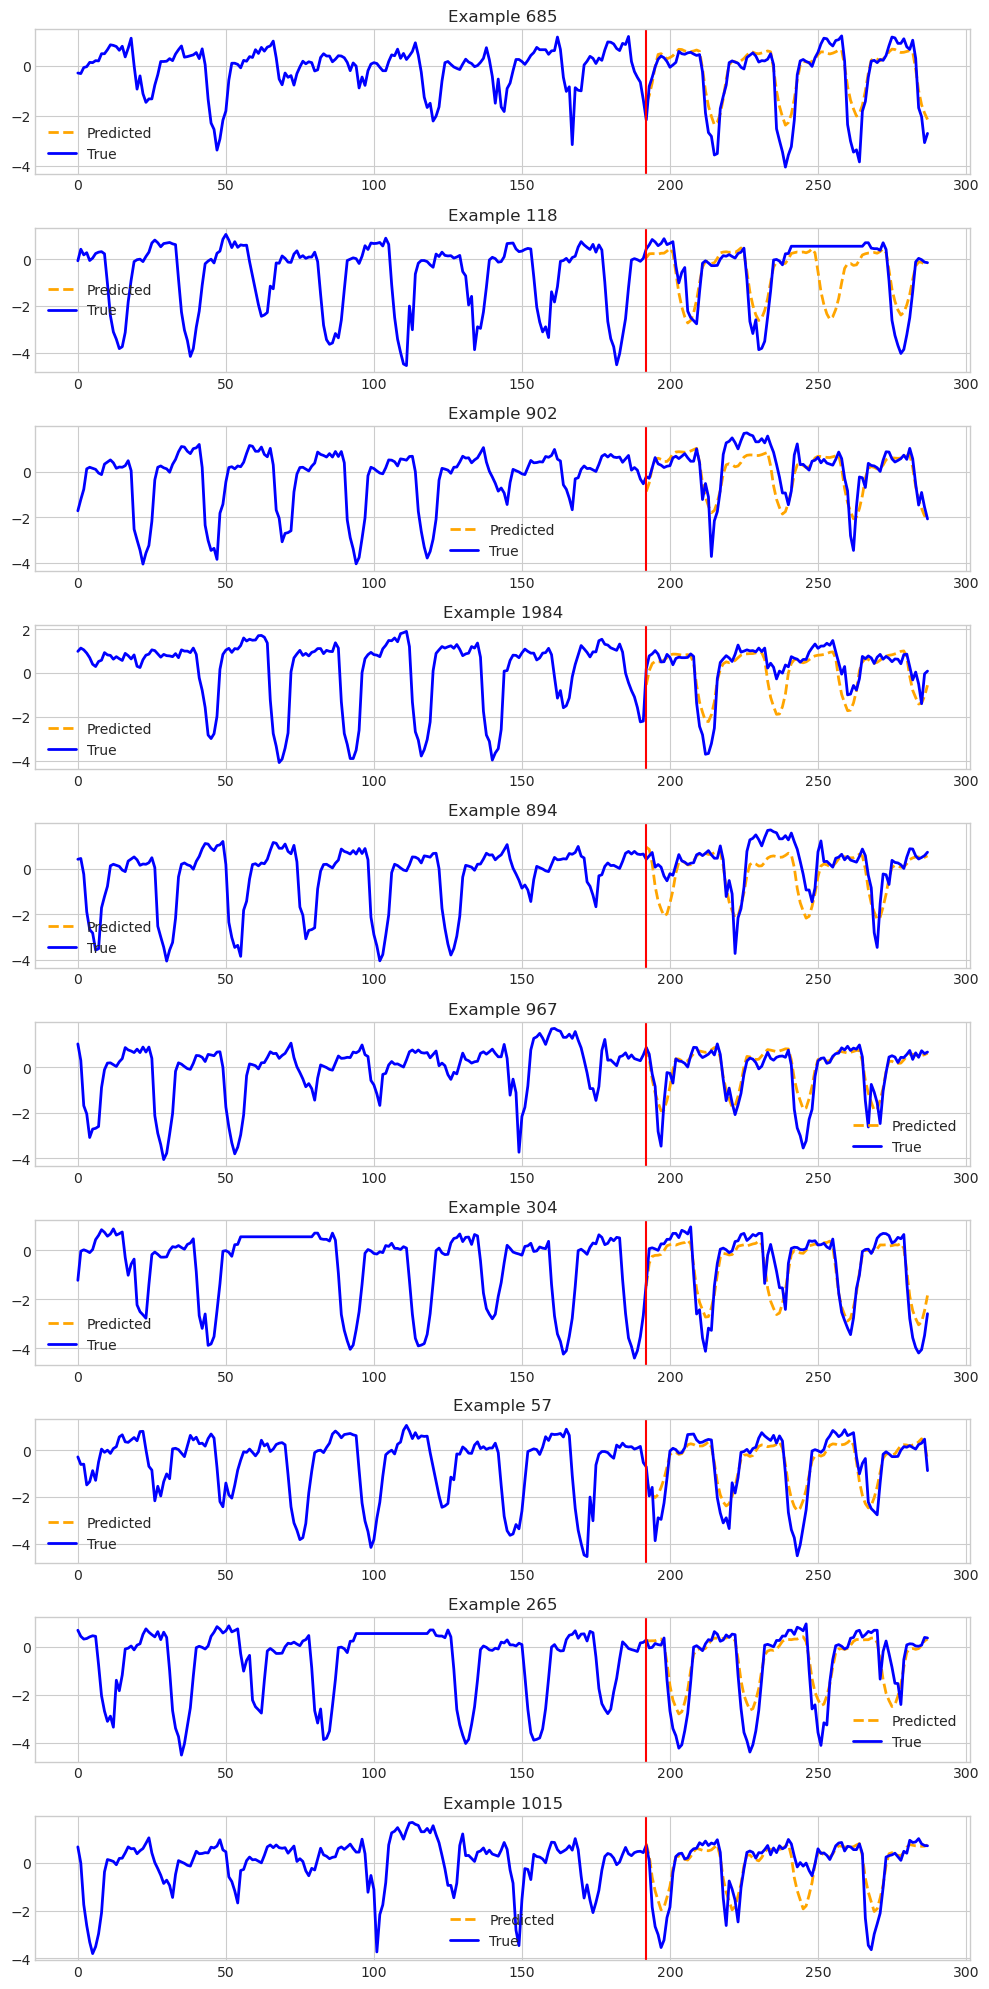

In [7]:
zeroshot_eval(
    dataset_name=TARGET_DATASET, context_length=CONTEXT_LENGTH, forecast_length=PREDICTION_LENGTH, batch_size=64
)

 ## Few-shot finetune and evaluation method

In [8]:
def fewshot_finetune_eval(
    dataset_name,
    batch_size,
    learning_rate=None,
    context_length=512,
    forecast_length=96,
    fewshot_percent=5,
    freeze_backbone=True,
    num_epochs=50,
    save_dir=OUT_DIR,
    loss="mse",
    distribution_output=None,
    num_of_mixtures=None,
    mixture_base=None,
    mixture_mode='full',
    mixture_mean_reg = 1.e-4,
    mixture_var_reg = 1.0,
    quantile=0.5,
    return_model=False,
    early_stop_patience=10,
):
    out_dir = os.path.join(save_dir, dataset_name)

    print("-" * 20, f"Running few-shot {fewshot_percent}%", "-" * 20)

    # Data prep: Get dataset

    tsp = TimeSeriesPreprocessor(
        **column_specifiers,
        context_length=context_length,
        prediction_length=forecast_length,
        scaling=True,
        encode_categorical=False,
        scaler_type="standard",
    )

    dset_train, dset_val, dset_test = get_datasets(
        tsp, data, split_config, fewshot_fraction=fewshot_percent / 100, fewshot_location="first"
    )

    # change head dropout to 0.7 for ett datasets
    if "ett" in dataset_name:
        finetune_forecast_model = get_model(
            TTM_MODEL_PATH,
            context_length=context_length,
            prediction_length=forecast_length,
            head_dropout=0.7,
            loss=loss,
            quantile=quantile,
            distribution_output=distribution_output,
            num_of_mixtures=num_of_mixtures,
            mixture_base=mixture_base,
            mixture_mode=mixture_mode,
            mixture_mean_reg=mixture_mean_reg,
            mixture_var_reg=mixture_var_reg,
        )
    else:
        finetune_forecast_model = get_model(
            TTM_MODEL_PATH,
            context_length=context_length,
            prediction_length=forecast_length,
            loss=loss,
            quantile=quantile,
            distribution_output=distribution_output,
            num_of_mixtures=num_of_mixtures,
            mixture_base=mixture_base,
            mixture_mode=mixture_mode,
            mixture_mean_reg=mixture_mean_reg,
            mixture_var_reg=mixture_var_reg,
        )

    if freeze_backbone:
        print(
            "Number of params before freezing backbone",
            count_parameters(finetune_forecast_model),
        )

        # Freeze the backbone of the model
        for param in finetune_forecast_model.backbone.parameters():
            param.requires_grad = False

        # Count params
        print(
            "Number of params after freezing the backbone",
            count_parameters(finetune_forecast_model),
        )

    # Find optimal learning rate
    # Use with caution: Set it manually if the suggested learning rate is not suitable
    if learning_rate is None:
        learning_rate, finetune_forecast_model = optimal_lr_finder(
            finetune_forecast_model,
            dset_train,
            batch_size=batch_size,
        )
        print("OPTIMAL SUGGESTED LEARNING RATE =", learning_rate)

    print(f"Using learning rate = {learning_rate}")
    finetune_forecast_args = TrainingArguments(
        output_dir=os.path.join(out_dir, "output"),
        overwrite_output_dir=True,
        learning_rate=learning_rate,
        num_train_epochs=num_epochs,
        do_eval=True,
        evaluation_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        dataloader_num_workers=8,
        report_to="none",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        logging_dir=os.path.join(out_dir, "logs"),  # Make sure to specify a logging directory
        load_best_model_at_end=True,  # Load the best model when training ends
        metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
        greater_is_better=False,  # For loss
        seed=SEED,
    )

    # Create the early stopping callback
    early_stopping_callback = EarlyStoppingCallback(
        early_stopping_patience=early_stop_patience,  # Number of epochs with no improvement after which to stop
        early_stopping_threshold=1e-5,  # Minimum improvement required to consider as improvement
    )
    tracking_callback = TrackingCallback()

    # Optimizer and scheduler
    optimizer = AdamW(finetune_forecast_model.parameters(), lr=learning_rate)
    scheduler = OneCycleLR(
        optimizer,
        learning_rate,
        epochs=num_epochs,
        steps_per_epoch=math.ceil(len(dset_train) / (batch_size)),
    )

    finetune_forecast_trainer = Trainer(
        model=finetune_forecast_model,
        args=finetune_forecast_args,
        train_dataset=dset_train,
        eval_dataset=dset_val,
        callbacks=[early_stopping_callback, tracking_callback],
        optimizers=(optimizer, scheduler),
    )
    finetune_forecast_trainer.remove_callback(INTEGRATION_TO_CALLBACK["codecarbon"])

    # Fine tune
    finetune_forecast_trainer.train()

    # Evaluation
    print("+" * 20, f"Test MSE after few-shot {fewshot_percent}% fine-tuning", "+" * 20)

    finetune_forecast_trainer.model.loss = "mse"  # fixing metric to mse for evaluation

    fewshot_output = finetune_forecast_trainer.evaluate(dset_test)
    print(fewshot_output)
    print("+" * 60)

    # get predictions

    predictions_dict = finetune_forecast_trainer.predict(dset_test)

    predictions_np = predictions_dict.predictions[0]

    #print(predictions_np.shape)

    # get backbone embeddings (if needed for further analysis)

    backbone_embedding = predictions_dict.predictions[1]

    print(backbone_embedding.shape)

    # plot
    plot_predictions(
        model=finetune_forecast_trainer.model,
        dset=dset_test,
        plot_dir=os.path.join(OUT_DIR, dataset_name),
        plot_prefix="test_fewshot",
        indices=[685, 118, 902, 1984, 894, 967, 304, 57, 265, 1015],
        channel=0,
    )

    if return_model:
        return finetune_forecast_trainer.model

### Few-shot 5%

fewshot_percent=80

fewshot_finetune_eval(
    dataset_name=TARGET_DATASET,
    context_length=CONTEXT_LENGTH,
    forecast_length=PREDICTION_LENGTH,
    batch_size=64,
    fewshot_percent=fewshot_percent,
    learning_rate=0.001,
)

INFO:p-2827180:t-22896113178432:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
Some weights of the model checkpoint at ibm-granite/granite-timeseries-ttm-r2 were not used when initializing TinyTimeMixerForPrediction: ['head.base_forecast_block.bias', 'head.base_forecast_block.weight']
- This IS expected if you are initializing TinyTimeMixerForPrediction from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TinyTimeMixerForPrediction from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of TinyTimeMixerForPrediction were not initialized from the model checkpoint at ibm-granite/granite-timeseries-ttm-r2 and are newly initialized: ['head.base_forecast_block.encoder.

-------------------- Running few-shot 80% --------------------
Mixture of 20 Normal distributions
Number of params before freezing backbone 5713100
Number of params after freezing the backbone 5197516
Using learning rate = 0.0005


Epoch,Training Loss,Validation Loss
1,72.918900,23.881395
2,21.329600,21.783892
3,11.108200,17.493229
4,9.760500,15.655044
5,8.602500,13.844030
6,7.944900,13.307983
7,7.586800,13.054914
8,7.319400,12.848365
9,7.063300,12.800016
10,6.851700,12.904164


[TrackingCallback] Mean Epoch Time = 1.8835759162902832 seconds, Total Train Time = 49.97138333320618
++++++++++++++++++++ Test MSE after few-shot 80% fine-tuning ++++++++++++++++++++


{'eval_loss': 0.3639019727706909, 'eval_runtime': 0.6319, 'eval_samples_per_second': 4407.349, 'eval_steps_per_second': 69.631, 'epoch': 19.0}
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
(2785, 7, 8, 192)


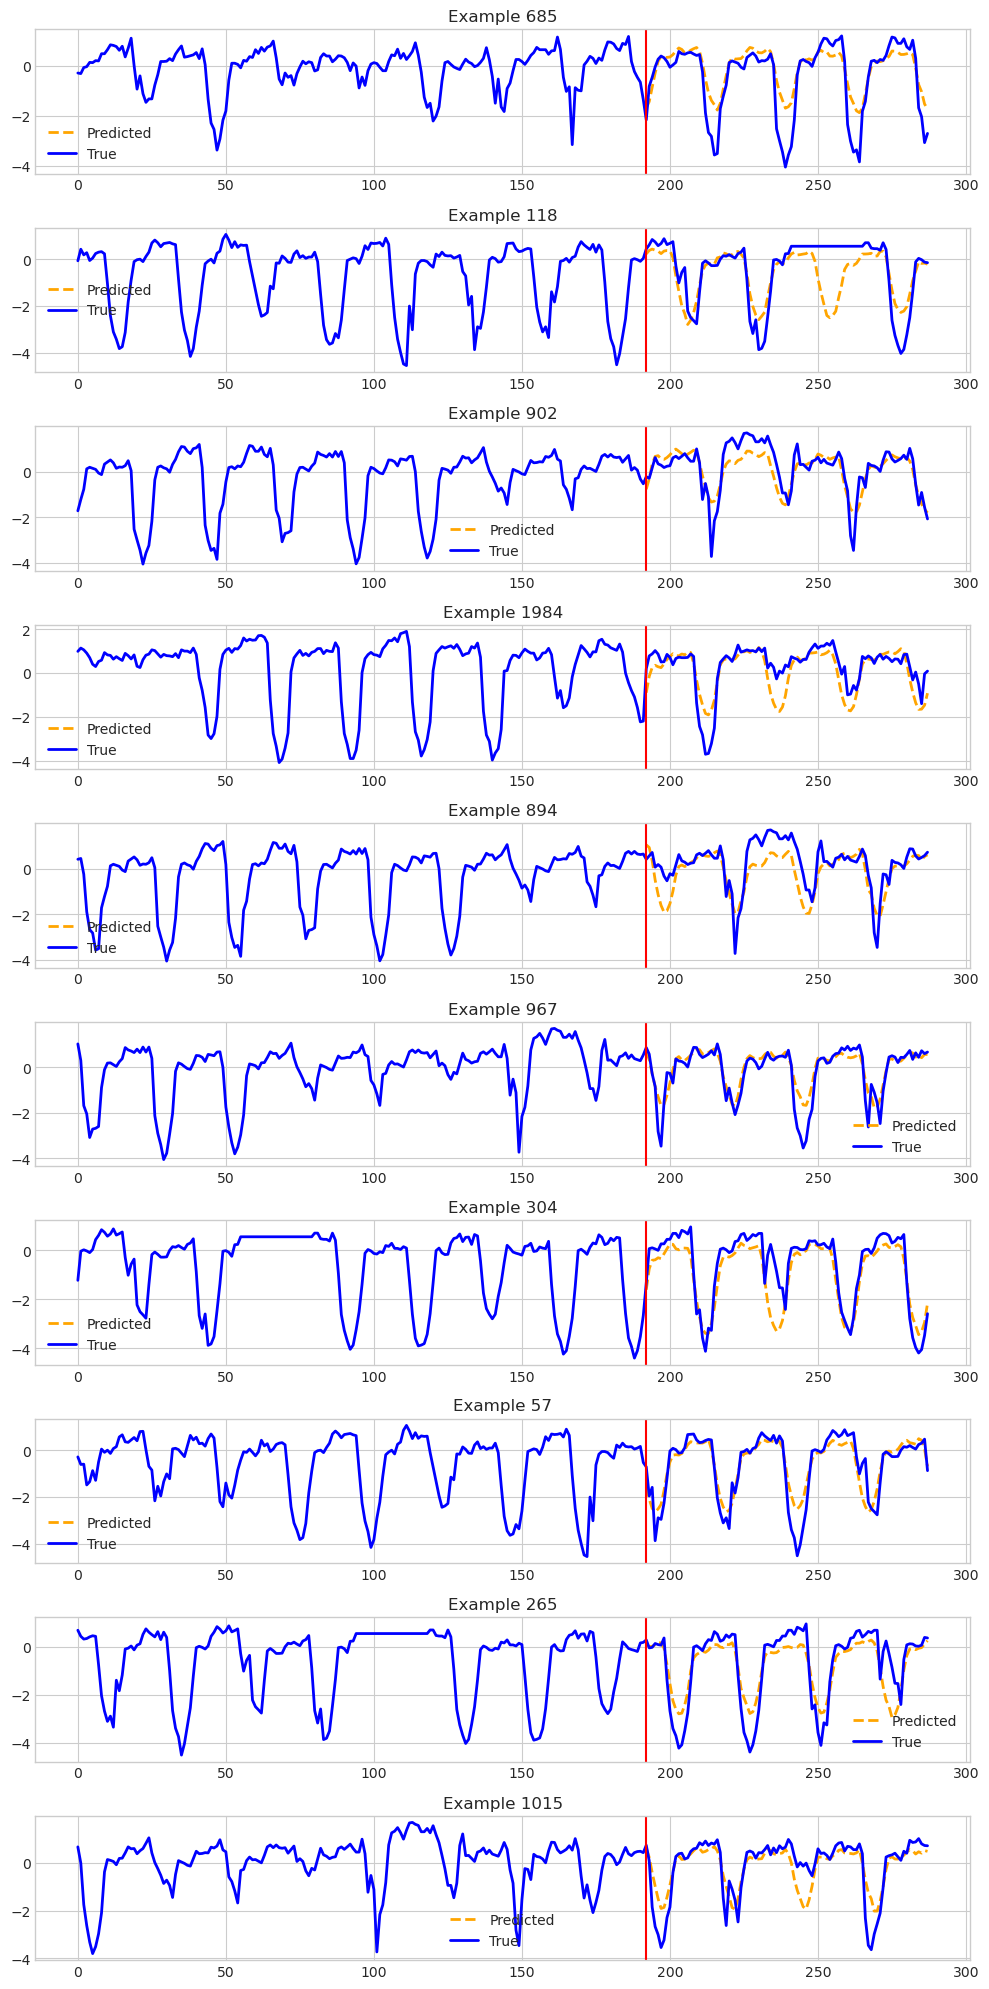

In [9]:
fewshot_percent=80
model = \
fewshot_finetune_eval(
    dataset_name=TARGET_DATASET,
    context_length=CONTEXT_LENGTH,
    forecast_length=PREDICTION_LENGTH,
    batch_size=64,
    fewshot_percent=fewshot_percent,
    learning_rate=0.0005,
    loss="nll",
    distribution_output='mixture',
    num_of_mixtures=20,
    mixture_base='normal',
    mixture_mode='full',
    mixture_mean_reg = 0.0,
    mixture_var_reg = 10.0,
    return_model=True,
)

In [10]:
#First Get Data

tsp = TimeSeriesPreprocessor(
    **column_specifiers,
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    scaling=True,
    encode_categorical=False,
    scaler_type="standard",
)

dset_train, dset_val, dset_test = get_datasets(
    tsp, data, split_config, fewshot_fraction=fewshot_percent / 100, fewshot_location="first"
)

In [11]:
import inspect
import torch
import numpy as np
from matplotlib import pyplot as plt

signature = inspect.signature(model.forward)
signature_keys = list(signature.parameters.keys())
signature_keys

#indices=[i for i in range(10)]
#data = dset_train

indices=[685, 118, 902, 1984, 894, 967, 304, 57, 265, 1015]
in_data = dset_test

dset_keys = in_data[0].keys()
random_samples = {}
for k in dset_keys:
    if k in signature_keys:
        random_samples[k] = torch.stack([in_data[i][k] for i in indices]).to(device=model.device)
output = model(**random_samples)

In [12]:
len(dset_train)

6407

In [13]:
#predict quantiles
pred_int = model.predict_quantile([0.025,0.5,0.975],past_values=random_samples['past_values']).sequences.detach().cpu()

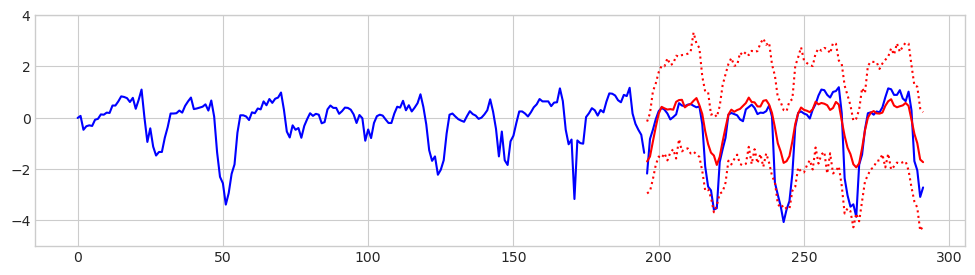

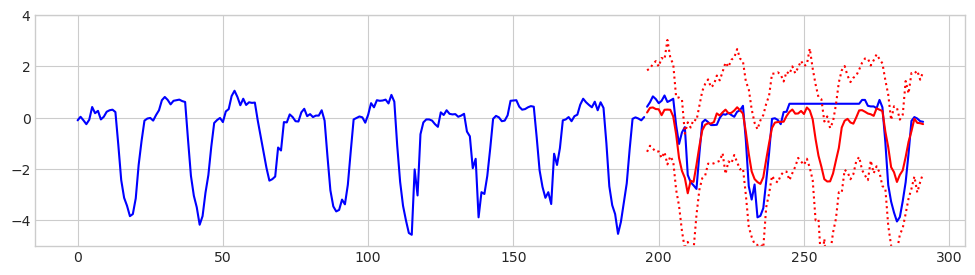

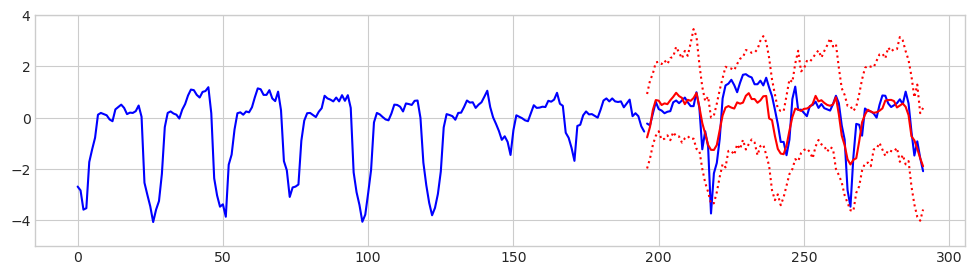

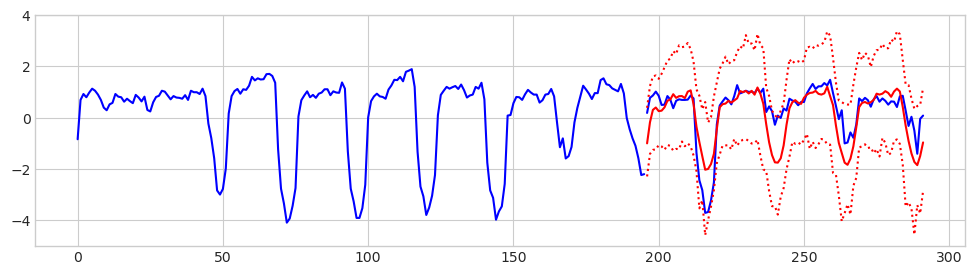

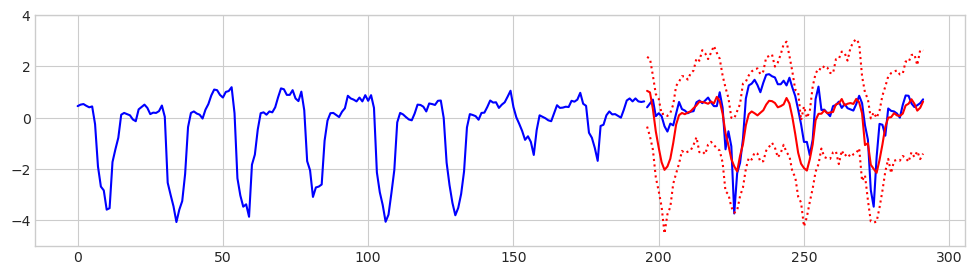

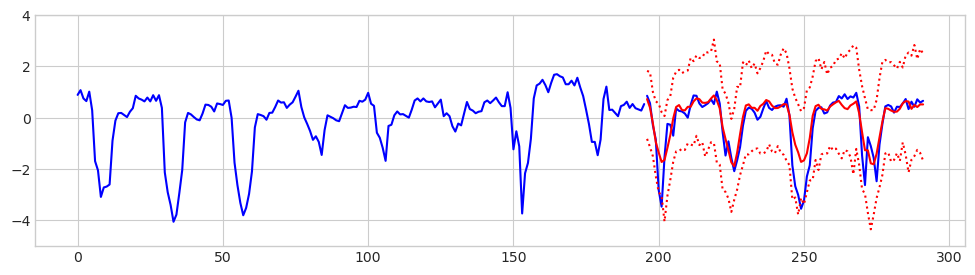

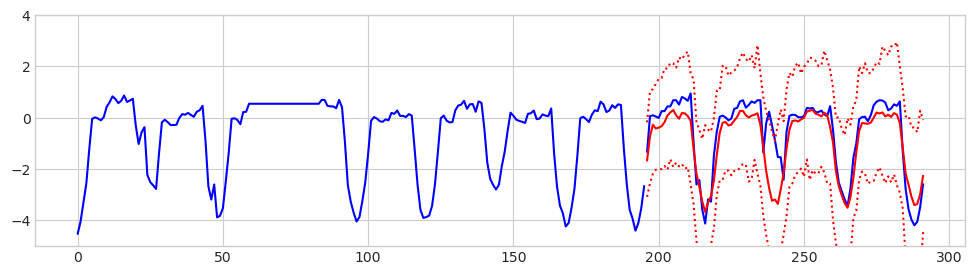

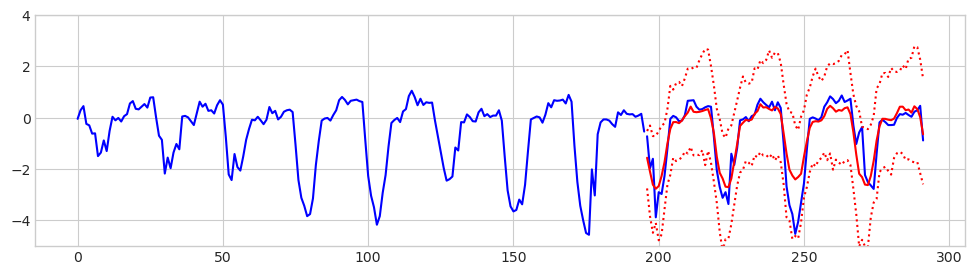

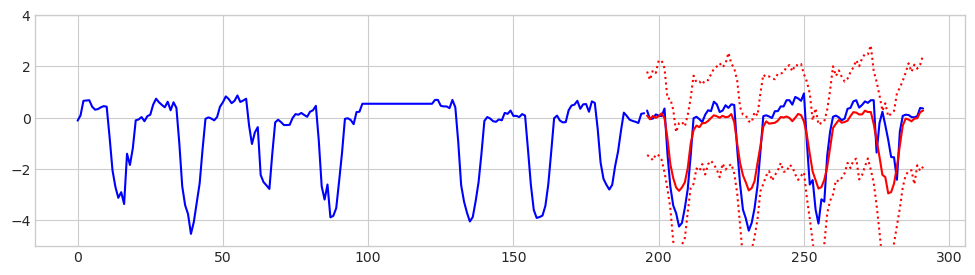

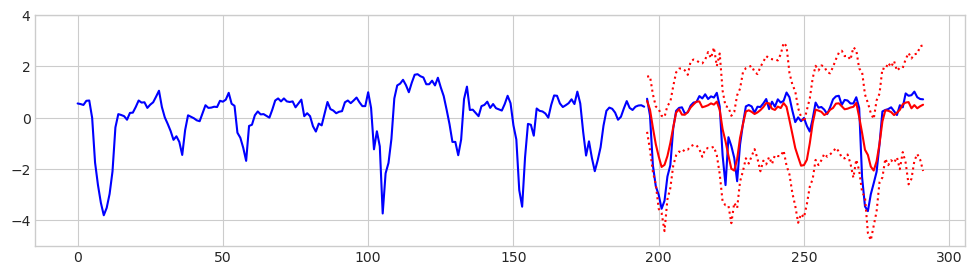

In [14]:
plot_past = 196
plot_pred = pred_int.size(2)

T_past   = np.arange(plot_past)
T_future = np.arange(plot_pred)+plot_past 

for i in range(pred_int.size(0)):
    plt.figure(figsize=(12,3))
    plt.plot(T_past  ,random_samples['past_values'][i,-plot_past:,0].cpu(),color='blue')
    plt.plot(T_future,random_samples['future_values'][i,:,0].cpu(),color='blue')
    plt.plot(T_future,pred_int[i,1,:,0],color='red')
    plt.plot(T_future,pred_int[i,0,:,0],color='red',linestyle=':')
    plt.plot(T_future,pred_int[i,2,:,0],color='red',linestyle=':')
    plt.ylim([-5,4])

In [15]:
random_samples['past_values'].size()

torch.Size([10, 512, 7])

In [16]:
model.loss = 'nll'
outputs = model(past_values=random_samples['past_values'])
pred_distribution = model.distribution_output.distribution(outputs.prediction_outputs, loc=outputs.loc, scale=outputs.scale)

In [17]:
pred_distribution.mean.size()

torch.Size([10, 96, 7])

In [18]:
pred_distribution.base_dist.component_distribution.base_dist.loc.size()

torch.Size([10, 96, 20, 7])

In [19]:
pred_distribution.base_dist.component_distribution.base_dist.scale[:,0,:,0]

tensor([[0.6005, 0.8286, 1.0170, 0.4495, 0.8413, 0.8914, 0.4025, 0.5724, 0.5367,
         0.8273, 0.6860, 0.5813, 0.4133, 1.2865, 0.9586, 0.4402, 0.5990, 0.8999,
         0.8299, 0.6414],
        [0.7117, 0.7700, 0.9653, 0.5794, 0.8097, 0.7336, 0.4918, 0.6506, 0.6792,
         0.6898, 0.7131, 0.7501, 0.7637, 1.1534, 1.1296, 0.6356, 0.7841, 0.9143,
         0.8271, 0.7032],
        [0.6821, 0.8270, 1.0234, 0.5075, 0.8115, 0.8476, 0.4721, 0.6123, 0.6691,
         0.7732, 0.6771, 0.7259, 0.5677, 1.1514, 1.1293, 0.5040, 0.6611, 0.8706,
         0.8738, 0.6642],
        [0.6860, 0.8838, 1.0654, 0.5249, 0.8276, 0.8728, 0.4431, 0.6413, 0.6283,
         0.8377, 0.6914, 0.6628, 0.5144, 1.2082, 0.9965, 0.5353, 0.6946, 0.9004,
         0.9342, 0.6478],
        [0.6101, 0.7138, 0.8947, 0.4372, 0.8254, 0.7390, 0.3900, 0.6023, 0.5649,
         0.6146, 0.6339, 0.5533, 0.6255, 1.3881, 1.1334, 0.6245, 0.8783, 0.8834,
         0.6511, 0.5938],
        [0.6042, 0.6717, 0.9185, 0.3813, 0.8094, 0.7705, 0.3

In [20]:
pred_distribution.variance[0,:,0]

tensor([0.4431, 0.5804, 0.6453, 0.7140, 0.7359, 0.7517, 0.7402, 0.8020, 0.6633,
        0.6603, 0.9145, 0.8430, 1.0081, 0.9496, 0.9591, 1.0493, 1.2890, 1.3159,
        1.1578, 0.8674, 0.7984, 0.9814, 0.8352, 0.7842, 0.8747, 0.8545, 0.8510,
        0.9403, 0.8636, 0.9758, 0.8555, 0.9008, 0.9301, 0.8928, 1.0514, 0.9576,
        1.2106, 1.0290, 1.2710, 1.2499, 1.2673, 1.3711, 1.3457, 1.2720, 1.3302,
        0.9503, 1.0419, 0.9491, 0.8308, 1.0426, 0.9721, 1.0744, 1.1478, 1.1937,
        1.0472, 1.0241, 0.8857, 1.0446, 0.9545, 0.9855, 0.9935, 1.0375, 1.2226,
        1.1292, 1.1971, 1.2275, 1.2373, 1.0747, 1.2700, 1.1466, 1.0964, 0.9137,
        0.8713, 1.0429, 1.1094, 1.0537, 1.1267, 1.2236, 0.9773, 0.9555, 0.8377,
        0.8374, 1.0427, 1.0340, 1.2099, 1.0552, 1.0849, 1.3890, 1.3062, 1.2614,
        1.2375, 1.5084, 1.4961, 1.4288, 1.5680, 1.1036], device='cuda:0',
       grad_fn=<SelectBackward0>)

In [21]:
pred_distribution.base_dist.mixture_distribution.probs[0,50,:]

tensor([0.0282, 0.0224, 0.0178, 0.1200, 0.0375, 0.0127, 0.1902, 0.0309, 0.0566,
        0.0114, 0.0478, 0.0847, 0.0742, 0.0070, 0.0106, 0.0946, 0.0892, 0.0094,
        0.0255, 0.0292], device='cuda:0', grad_fn=<SliceBackward0>)

In [22]:
pred_distribution.base_dist.component_distribution.base_dist.scale[0,50,:,0]

tensor([0.5120, 0.8414, 0.8725, 0.2464, 0.6900, 0.8835, 0.3096, 0.5387, 0.3893,
        0.8906, 0.3663, 0.3856, 0.4187, 1.4584, 1.4918, 0.2951, 0.3860, 1.0474,
        0.9577, 0.4450], device='cuda:0', grad_fn=<SelectBackward0>)

In [23]:
pred_distribution.stddev[0,:,0]

tensor([0.6657, 0.7618, 0.8033, 0.8450, 0.8579, 0.8670, 0.8603, 0.8956, 0.8145,
        0.8126, 0.9563, 0.9182, 1.0040, 0.9745, 0.9794, 1.0244, 1.1354, 1.1471,
        1.0760, 0.9313, 0.8936, 0.9907, 0.9139, 0.8855, 0.9353, 0.9244, 0.9225,
        0.9697, 0.9293, 0.9878, 0.9249, 0.9491, 0.9644, 0.9449, 1.0254, 0.9786,
        1.1003, 1.0144, 1.1274, 1.1180, 1.1258, 1.1709, 1.1600, 1.1279, 1.1533,
        0.9748, 1.0208, 0.9742, 0.9115, 1.0211, 0.9859, 1.0365, 1.0714, 1.0925,
        1.0233, 1.0120, 0.9411, 1.0221, 0.9770, 0.9927, 0.9967, 1.0186, 1.1057,
        1.0626, 1.0941, 1.1079, 1.1123, 1.0367, 1.1270, 1.0708, 1.0471, 0.9559,
        0.9334, 1.0212, 1.0533, 1.0265, 1.0614, 1.1062, 0.9886, 0.9775, 0.9153,
        0.9151, 1.0211, 1.0169, 1.0999, 1.0272, 1.0416, 1.1785, 1.1429, 1.1231,
        1.1125, 1.2282, 1.2232, 1.1953, 1.2522, 1.0505], device='cuda:0',
       grad_fn=<SelectBackward0>)

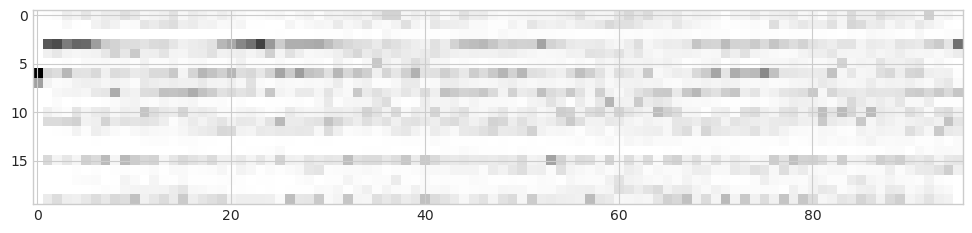

In [24]:
mix = pred_distribution.base_dist.mixture_distribution.probs.detach().cpu()
plt.figure(figsize=(12,4))
plt.imshow(mix[0].t(),cmap='binary')

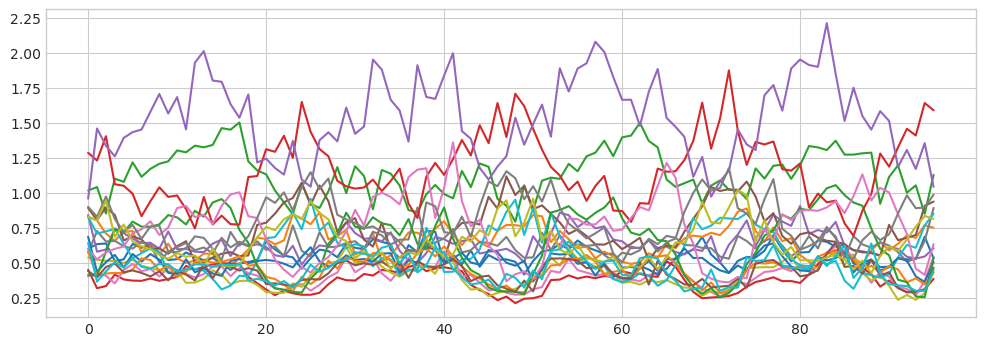

In [25]:
plt.figure(figsize=(12,4))
plt.plot(pred_distribution.base_dist.component_distribution.base_dist.scale[0,:,:,0].detach().cpu())

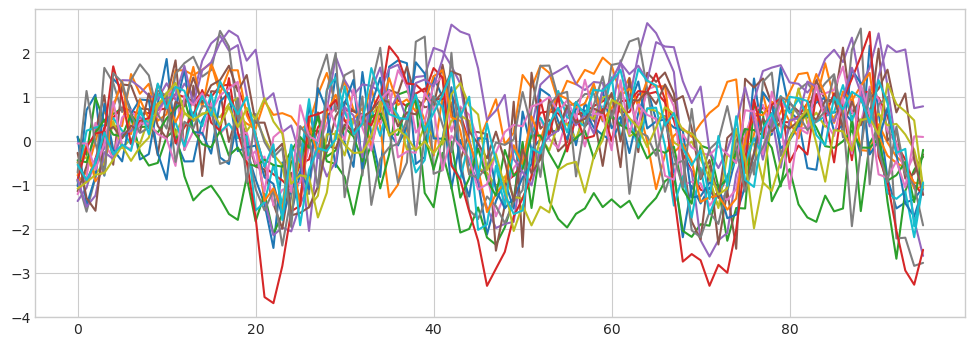

In [26]:
plt.figure(figsize=(12,4))
plt.plot(pred_distribution.base_dist.component_distribution.base_dist.loc[0,:,:,0].detach().cpu())

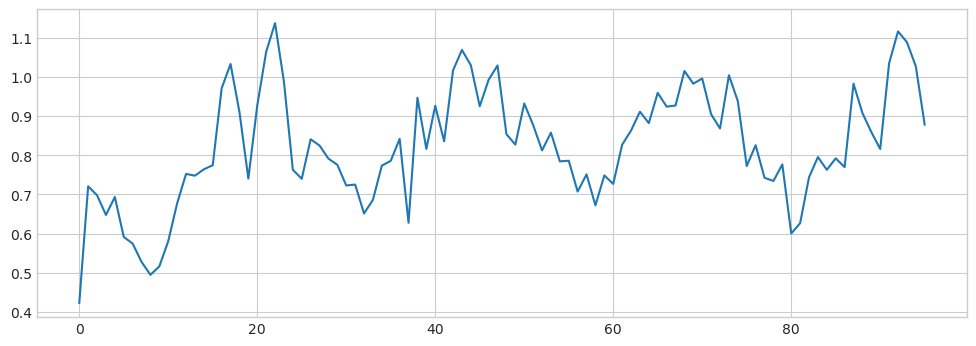

In [31]:
plt.figure(figsize=(12,4))
plt.plot(pred_distribution.base_dist.component_distribution.base_dist.loc[0,:,:,0].detach().cpu().std(1))

In [32]:
pred_distribution.scale.size()

torch.Size([10, 1, 7])